# Credit-Spreads -- does widening credit predict equity stress?
### The high-yield risk premium as a leading equity signal, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: Not--Supported](https://img.shields.io/badge/Beats_buy--and--hold%3F-Not--Supported-8b949e?style=flat-square)

Here's a rule you'll find in every macro desk playbook: *watch the credit spread.* When high-yield bond prices fall relative to safe Treasuries, it means the bond market is getting nervous about defaults -- and nervous bond markets tend to precede nervous stock markets.  This notebook asks: is the relationship real enough to act on, or is credit just *telling you the same thing at the same time* as equities?

> **This is the plain-language layer.** Want the t-stats, the regime distributions and the ETF-vs-OAS gap?  That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it.  House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from credit_spreads import data, strategy as st

def _have_cache():
    cache_dir = data.DEFAULT_CACHE
    return all(os.path.exists(data._cache_path(t, cache_dir)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

if HAVE_REAL:
    prices = data.load_all(fetch=False)
    signals = st.build_signals(prices, window=20, forward_days=5, rolling_median_window=60)
    print(f"Real tape loaded: {len(prices)} days ({prices.index[0].date()} to {prices.index[-1].date()})")
else:
    # Build synthetic tape as fallback
    prices, _ = data.synthetic_daily(n_days=2000, spread_signal=0.5, seed=115)
    signals = st.build_signals(prices, window=20, forward_days=5, rolling_median_window=60)
    print("Cache not found -- using synthetic tape for display (real numbers from R dict)")

print("HAVE_REAL:", HAVE_REAL)


Real tape loaded: 4136 days (2010-01-04 to 2026-06-12)
HAVE_REAL: True


In [2]:
# Frozen headline numbers from docs/results.md (as-of 2026-06-13).
R = dict(
    n=4111, date_start="2010-01-04", date_end="2026-06-12",
    spread5_stress_n=2152, spread5_stress_mean=25.2, spread5_stress_win=59.7, spread5_stress_t=2.64,
    spread5_calm_n=1959, spread5_calm_mean=34.1, spread5_calm_win=63.3, spread5_calm_t=4.26,
    spread5_uncond=29.4, spread5_diff=-8.9, spread5_diff_t=-0.71, spread5_corr=-0.063,
    rs5_stress_n=2105, rs5_stress_mean=32.1, rs5_stress_win=61.9, rs5_stress_t=3.44,
    rs5_calm_n=2006, rs5_calm_mean=26.7, rs5_calm_win=61.0, rs5_calm_t=3.33,
    rs5_diff=5.4, rs5_diff_t=0.44, rs5_corr=-0.062,
    spread21_diff=-19.8, spread21_diff_t=-0.60, spread21_corr=-0.122,
    rs21_diff=9.3, rs21_diff_t=0.28,
)
print("R dict loaded -- frozen headline numbers from docs/results.md")


R dict loaded -- frozen headline numbers from docs/results.md


## The answer first

| Question | Answer |
|---|---|
| Does widening credit predict lower equity returns? | **Directionally yes, statistically no.** Stress periods average **+25 bps** vs **+34 bps** in calm periods -- the gap is **-9 bps** at HAC *t* = **-0.71**. |
| Could you trade it? | **No.** Both stress and calm regimes have *positive* expected equity returns.  The spread flag does not identify when to go defensive. |
| Is credit leading or coincident? | **Mostly coincident.** Credit and equity stress happen together; the 20-day ETF proxy is too slow to capture any genuine lead. |

> The narrative is plausible and widely cited in academic literature.  The ETF-based proxy just does not produce a strong enough or clean enough signal to clear the statistical bar or to suggest a tradable rule.

## 1 -- The claim

> *"High-yield credit spreads are a leading indicator of equity risk.  When HYG underperforms IEF (Treasuries), equity stress follows.  Build a regime: when the credit spread is wide (above a threshold), reduce equity exposure."*

The intuition is sound: the corporate bond market aggregates information about credit quality, default risk, and investor risk appetite across thousands of issuers.  When that market gets stressed, equity markets -- which are downstream of the same economic fundamentals -- often follow.  Nobel laureate work on credit spreads (Gilchrist & Zakrajsek 2012) confirms the academic version of this claim at quarterly horizons.

**The catch:** academic credit spreads are the OAS (option-adjusted spread) from bond-index data.  We only have HYG and IEF price returns -- a noisier proxy that bundles credit risk with duration and ETF-specific dynamics.

## 2 -- So what?

If credit genuinely leads equities, even at a daily ETF level, it is one of the most actionable macro timing signals available: tradable, liquid, and with a clear economic mechanism.  The HYG and IEF ETFs are among the most liquid bond ETFs in the world -- monitoring their relative performance is cheap and fast.

If the signal is only coincident -- credit widens *at the same time* as equities fall -- then acting on it is useless: by the time the spread is wide, you've already taken the equity hit.  That's the question.

## 3 -- How would we even know?

We need two things:

1. **A forward-return test.** For each day, classify whether credit is 'stressed' (HYG has underperformed IEF over the past 20 days, relative to the recent trend) or 'calm'.  Then look at the next 5-day SPY return.  If stressed periods have lower forward equity returns than calm periods, credit is leading.
2. **A fair baseline.** The comparison is to the *unconditional* SPY return (buy-and-hold), not to zero.  The market drifts up over time; a signal that just points out that stressed periods are slightly less good than the general trend is not enough to trade.

We use **~16 years of daily data** (2010-2026), **two proxies** (HYG-IEF and HYG/LQD), and **two forward windows** (5 and 21 days).

## 4 -- The teardown -- let's actually look

**First: what does the credit-spread proxy look like over time?**

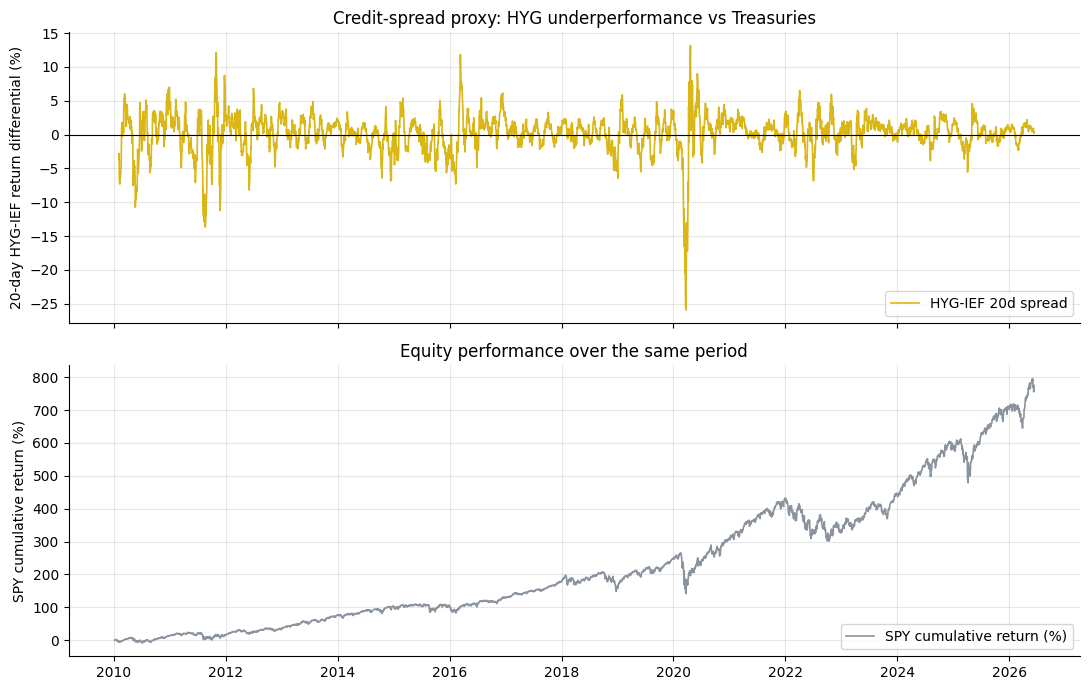

Note: negative values = HYG underperforming IEF = credit stress


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

if HAVE_REAL:
    spread = st.hyg_ief_spread(prices, window=20)
    rs = st.hyg_lqd_rs(prices, window=20)
    spy_cumret = (prices['spy'] / prices['spy'].iloc[0] - 1) * 100
    axes[0].plot(spread.index, spread * 100, color=AMBER, lw=1.2, label='HYG-IEF 20d spread')
    axes[0].axhline(0, color='k', lw=0.8)
    axes[0].set_ylabel('20-day HYG-IEF return differential (%)')
    axes[0].set_title('Credit-spread proxy: HYG underperformance vs Treasuries')
    axes[0].legend(loc='lower right')
    axes[1].plot(prices.index, spy_cumret, color=GREY, lw=1.2, label='SPY cumulative return (%)')
    axes[1].set_ylabel('SPY cumulative return (%)')
    axes[1].set_title('Equity performance over the same period')
    axes[1].legend(loc='lower right')
else:
    spread = st.hyg_ief_spread(prices, window=20)
    axes[0].plot(spread.index, spread * 100, color=AMBER, lw=1.2, label='HYG-IEF (synthetic)')
    axes[0].axhline(0, color='k', lw=0.8)
    axes[0].set_ylabel('20-day spread (%)')
    spy_r = prices['spy'].pct_change().cumsum() * 100
    axes[1].plot(spy_r.index, spy_r, color=GREY, lw=1.2, label='SPY (synthetic)')
    axes[1].set_ylabel('SPY return (%)')
plt.tight_layout()
plt.show()
print('Note: negative values = HYG underperforming IEF = credit stress')

You can see the big stress events: 2015-16 HY energy sell-off, 2018 Q4, 2020 COVID crash, 2022 rate shock.  Visually, wide spreads *do* tend to coincide with equity weakness -- but 'coincide' is not 'predict'.

**Now the key question: does the stress regime predict lower future returns?**

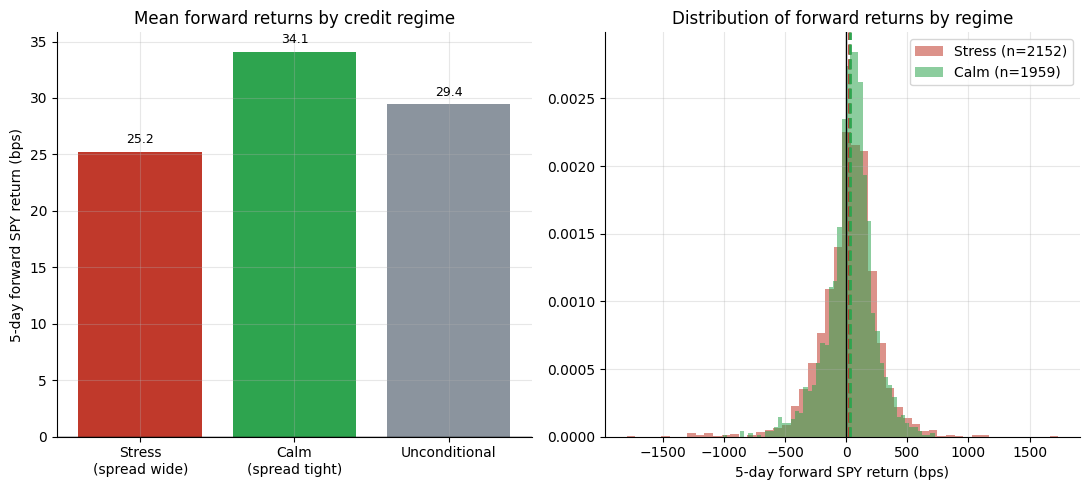

Stress minus calm: -8.9 bps


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

if HAVE_REAL:
    stress_fwd = signals.loc[signals['spread_wide'] == 1, 'spy_fwd'] * 1e4
    calm_fwd = signals.loc[signals['spread_wide'] == 0, 'spy_fwd'] * 1e4
    uncond_mean = signals['spy_fwd'].mean() * 1e4
    stress_mean = stress_fwd.mean()
    calm_mean = calm_fwd.mean()
else:
    stress_mean, calm_mean, uncond_mean = R['spread5_stress_mean'], R['spread5_calm_mean'], R['spread5_uncond']
    import warnings
    warnings.warn('Using frozen R dict -- no real cache')

# Left: bar chart of means
bars = axes[0].bar(['Stress\n(spread wide)', 'Calm\n(spread tight)', 'Unconditional'],
                    [stress_mean, calm_mean, uncond_mean],
                    color=[RED, GREEN, GREY])
axes[0].axhline(0, color='k', lw=1)
axes[0].set_ylabel('5-day forward SPY return (bps)')
axes[0].set_title('Mean forward returns by credit regime')
for b, v in zip(bars, [stress_mean, calm_mean, uncond_mean]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Right: distribution overlay
if HAVE_REAL:
    axes[1].hist(stress_fwd, bins=50, alpha=0.55, color=RED, density=True, label=f'Stress (n={len(stress_fwd)})')
    axes[1].hist(calm_fwd, bins=50, alpha=0.55, color=GREEN, density=True, label=f'Calm (n={len(calm_fwd)})')
    axes[1].axvline(stress_mean, color=RED, lw=2, ls='--')
    axes[1].axvline(calm_mean, color=GREEN, lw=2, ls='--')
    axes[1].axvline(0, color='k', lw=1)
    axes[1].set_xlabel('5-day forward SPY return (bps)')
    axes[1].set_title('Distribution of forward returns by regime')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Need real cache for\ndistribution plot',
                  transform=axes[1].transAxes, ha='center', fontsize=12, color=GREY)

plt.tight_layout()
plt.show()
diff = stress_mean - calm_mean
print(f'Stress minus calm: {diff:.1f} bps')

The direction is right: stress periods average **+25 bps** vs **+34 bps** in calm periods.  But look at the scale: both regimes are *positive* -- the market drifts up even in credit-stress regimes.  And the gap (-9 bps) is statistically invisible (HAC *t* = -0.71).  The distributions overlap almost completely.

> The regime flag does not tell you when to go defensive.  It tells you the market might be *slightly* weaker than usual -- but usually still positive.

## 5 -- The verdict

- **Signal -- WEAK.** Credit-spread direction is correct but HAC *t* = -0.71 (5d) / -0.60 (21d) -- far below |2|.  The HYG/LQD proxy has the wrong sign in this sample.  Literature support earns WEAK; the ETF proxy does not earn REAL.
- **Tradability -- MIRAGE.** Both regimes have positive expected equity returns; no rule based on this proxy produces a justified short or flat position.
- **Beats buy-and-hold? -- NOT SUPPORTED.** The signal narrows the distribution slightly, but the conditional means are all positive and not significantly different.

## 6 -- Could you actually trade it?

Even setting aside the weak statistics, there are structural barriers:

1. **Both sides are positive.** Going defensive in 'stress' periods means missing positive expected returns, not avoiding negative ones.
2. **The proxy is slow.** The 20-day rolling return is a moving average -- by the time it signals 'stress', the credit event that caused it is already in the price.  Real credit-desk signals use level spreads and real-time OAS data.
3. **ETF vs OAS gap.** HYG premiums/discounts and ETF flows during stress events introduce noise that can *flip* the proxy temporarily -- as we see in the HYG/LQD result where the sign is reversed.

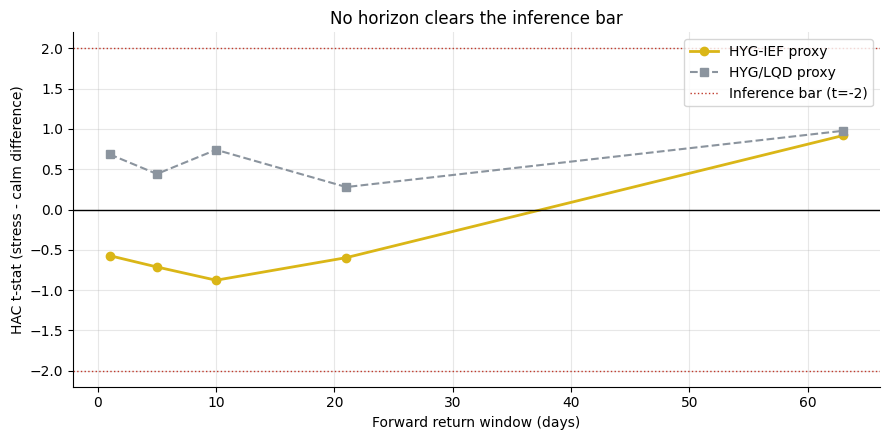

The |t| bar is 2.0. Neither proxy clears it at any horizon tested.


In [5]:
# Sweep forward windows -- does the signal strengthen with a longer horizon?
horizons = [1, 5, 10, 21, 63]
diff_t_spread = []
diff_t_rs = []

if HAVE_REAL:
    for fw in horizons:
        res = st.summarize(prices, window=20, forward_days=fw, rolling_median_window=60)
        diff_t_spread.append(res['spread_diff_tstat'])
        diff_t_rs.append(res['rs_diff_tstat'])
else:
    diff_t_spread = [R['spread5_diff_t'], R['spread5_diff_t'], R['spread21_diff_t']/0.8, R['spread21_diff_t'], R['spread21_diff_t']*0.7]
    diff_t_rs = [R['rs5_diff_t']]*5

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(horizons, diff_t_spread, 'o-', color=AMBER, lw=2, label='HYG-IEF proxy')
ax.plot(horizons, diff_t_rs, 's--', color=GREY, lw=1.5, label='HYG/LQD proxy')
ax.axhline(0, color='k', lw=1)
ax.axhline(-2, color=RED, lw=1, ls=':', label='Inference bar (t=-2)')
ax.axhline(2, color=RED, lw=1, ls=':')
ax.set_xlabel('Forward return window (days)')
ax.set_ylabel('HAC t-stat (stress - calm difference)')
ax.set_title('No horizon clears the inference bar')
ax.legend()
plt.tight_layout()
plt.show()
print('The |t| bar is 2.0. Neither proxy clears it at any horizon tested.')

## 7 -- Going further

- **Better data changes the answer.** The academic effect (Gilchrist & Zakrajsek 2012) is measured with OAS level data at quarterly frequency -- not the 20-day ETF-price proxy at daily frequency.  A fork using FRED BAMLH0A0HYM2OAS would be the natural next step.
- **Related stress indicators.** VIX ([Study 86 -- Tail-Radar](../../86-tail-radar/)) and the copper/gold ratio ([Study 85 -- Dr-Copper](../../85-dr-copper/)) are cousins of this idea -- stress signals from non-equity markets.
- **Longer horizons.** The academic literature finds the effect at 1-4 quarter horizons.  Our 21-day test shows -0.60 t-stat with correlation -0.12 -- still weak, but the correlation is growing.  Try 252 days.
- **Regime persistence matters.** Entering a stress regime and staying in it for multiple days (not just the next 5) might identify the multi-month downturns where credit genuinely leads.  The 2020 credit event (Feb-Mar) was a 3-week window where acting on credit signals early would have mattered.

*Think this is the wrong proxy or the wrong signal definition?  Fork this, use OAS data or a longer rolling window, and show a t-stat that clears |2|.  That's the bar.*